<a href="https://colab.research.google.com/github/oluwafemi244/facility-maintenance-energy-decision-support/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preliminary Exploratory Analysis of the AI4I 2020 Predictive Maintenance Dataset

## Facility Maintenance and Energy Decision Support Framework

This notebook documents the preliminary data evaluation stage of the maintenance workstream.

The purpose of this analysis is to inspect the AI4I 2020 Predictive Maintenance Dataset, verify its structure and quality, examine the distribution of machine failures and failure modes, and identify operating variables that may be suitable for later failure-risk modeling.

The AI4I dataset is synthetic. Results from this notebook are therefore proof-of-concept findings and are not presented as observations from an actual industrial facility.

This notebook does not produce operational maintenance recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
data_url = (
    "https://raw.githubusercontent.com/"
    "oluwafemi244/facility-maintenance-energy-decision-support/"
    "main/data/ai4i2020.csv"
)

df = pd.read_csv(data_url)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 10,000
Columns: 14


In [3]:
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:
1. UDI
2. Product ID
3. Type
4. Air temperature [K]
5. Process temperature [K]
6. Rotational speed [rpm]
7. Torque [Nm]
8. Tool wear [min]
9. Machine failure
10. TWF
11. HDF
12. PWF
13. OSF
14. RNF


In [4]:
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [5]:
print("Data types:\n")
print(df.dtypes)

Data types:

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [6]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Variable": missing_values.index,
    "Missing Values": missing_values.values
})

missing_table

,Variable,Missing Values
0,UDI,0
1,Product ID,0
2,Type,0
3,Air temperature [K],0
4,Process temperature [K],0
5,Rotational speed [rpm],0
6,Torque [Nm],0
7,Tool wear [min],0
8,Machine failure,0
9,TWF,0


In [7]:
print(f"Total missing values in dataset: {df.isnull().sum().sum()}")

Total missing values in dataset: 0


In [8]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [9]:
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


In [10]:
type_counts = df["Type"].value_counts().sort_index()

type_table = pd.DataFrame({
    "Product Type": type_counts.index,
    "Observations": type_counts.values,
    "Percentage": (type_counts.values / len(df) * 100).round(2)
})

type_table

,Product Type,Observations,Percentage
0,H,1003,10.03
1,L,6000,60.00
2,M,2997,29.97


In [11]:
failure_counts = df["Machine failure"].value_counts().sort_index()

failure_table = pd.DataFrame({
    "Machine Failure": failure_counts.index,
    "Observations": failure_counts.values,
    "Percentage": (failure_counts.values / len(df) * 100).round(2)
})

failure_table

,Machine Failure,Observations,Percentage
0,0,9661,96.61
1,1,339,3.39


In [12]:
failure_rate = df["Machine failure"].mean() * 100

print(f"Overall machine failure rate: {failure_rate:.2f}%")

Overall machine failure rate: 3.39%


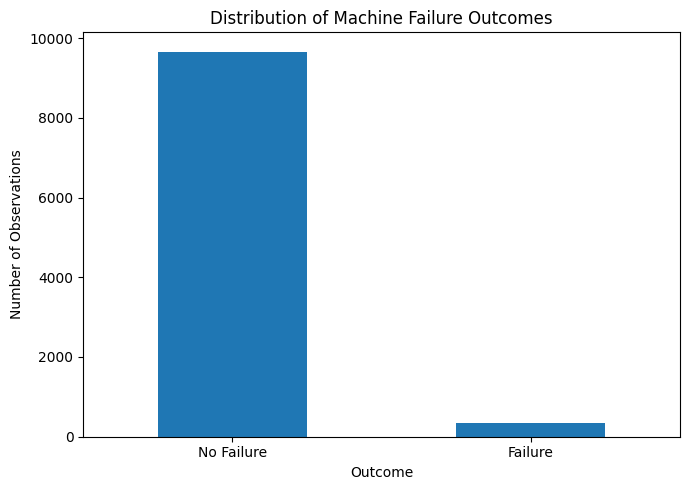

In [13]:
failure_labels = df["Machine failure"].map({
    0: "No Failure",
    1: "Failure"
})

counts = failure_labels.value_counts()

plt.figure(figsize=(7, 5))
counts.plot(kind="bar")
plt.title("Distribution of Machine Failure Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_mode_counts = df[failure_modes].sum().sort_values(ascending=False)

failure_mode_table = pd.DataFrame({
    "Failure Mode": failure_mode_counts.index,
    "Number of Occurrences": failure_mode_counts.values
})

failure_mode_table

,Failure Mode,Number of Occurrences
0,HDF,115
1,OSF,98
2,PWF,95
3,TWF,46
4,RNF,19


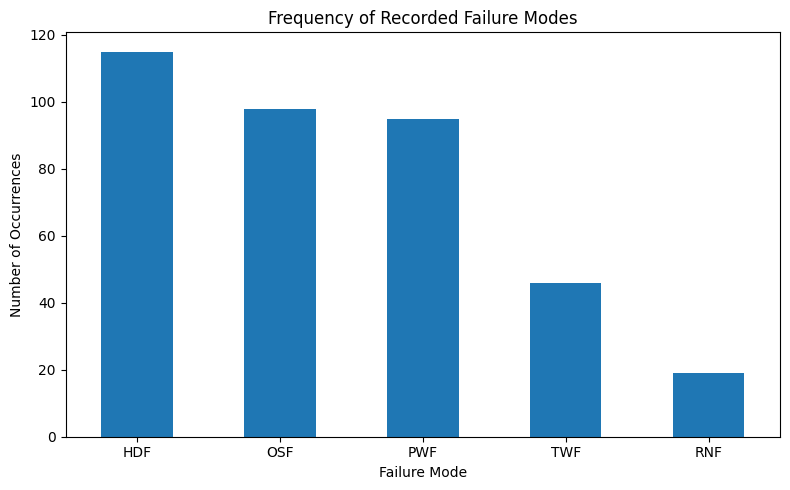

In [15]:
plt.figure(figsize=(8, 5))
failure_mode_counts.plot(kind="bar")
plt.title("Frequency of Recorded Failure Modes")
plt.xlabel("Failure Mode")
plt.ylabel("Number of Occurrences")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
failure_mode_sum = df[failure_modes].sum(axis=1)

inconsistent_general_failure = df[
    (df["Machine failure"] == 1) &
    (failure_mode_sum == 0)
]

failure_mode_without_general_failure = df[
    (df["Machine failure"] == 0) &
    (failure_mode_sum > 0)
]

print(
    "Machine failure = 1 but no listed failure mode:",
    len(inconsistent_general_failure)
)

print(
    "Listed failure mode present but Machine failure = 0:",
    len(failure_mode_without_general_failure)
)

Machine failure = 1 but no listed failure mode: 9
Listed failure mode present but Machine failure = 0: 18


In [17]:
failure_comparison = (
    df.groupby("Machine failure")[numeric_columns]
    .mean()
    .T
)

failure_comparison.columns = [
    "Mean - No Failure",
    "Mean - Failure"
]

failure_comparison

,Mean - No Failure,Mean - Failure
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


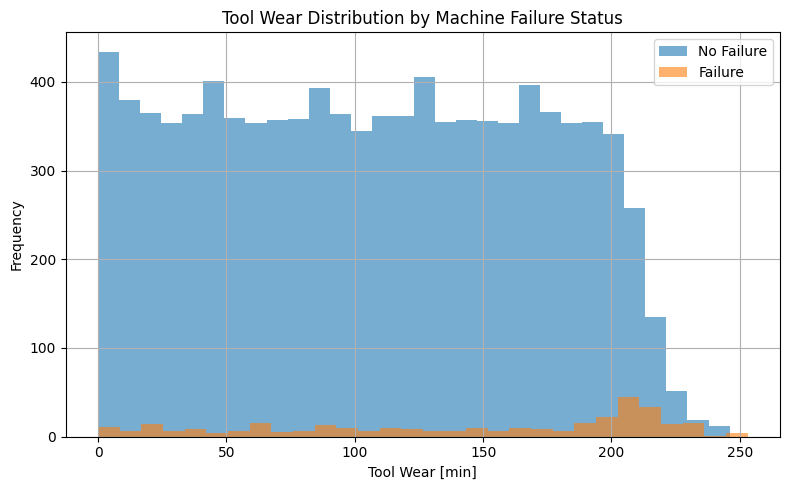

In [18]:
plt.figure(figsize=(8, 5))

df[df["Machine failure"] == 0]["Tool wear [min]"].hist(
    bins=30,
    alpha=0.6,
    label="No Failure"
)

df[df["Machine failure"] == 1]["Tool wear [min]"].hist(
    bins=30,
    alpha=0.6,
    label="Failure"
)

plt.title("Tool Wear Distribution by Machine Failure Status")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

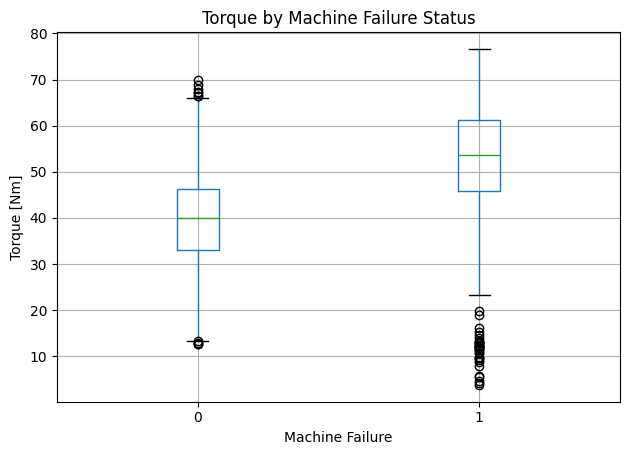

In [19]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Torque [Nm]",
    by="Machine failure"
)

plt.title("Torque by Machine Failure Status")
plt.suptitle("")
plt.xlabel("Machine Failure")
plt.ylabel("Torque [Nm]")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

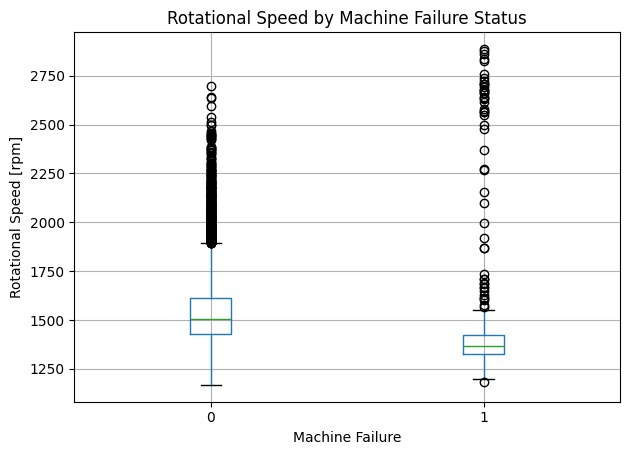

In [20]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Rotational speed [rpm]",
    by="Machine failure"
)

plt.title("Rotational Speed by Machine Failure Status")
plt.suptitle("")
plt.xlabel("Machine Failure")
plt.ylabel("Rotational Speed [rpm]")
plt.tight_layout()
plt.show()

## Preliminary Findings

The exploratory analysis confirmed that the AI4I 2020 dataset contains 10,000 observations and 14 variables. No missing values or duplicate rows were identified in the dataset.

Machine failures are relatively uncommon in the dataset. Of the 10,000 observations, 339 are labeled as machine failures, corresponding to an overall failure rate of 3.39%. This class imbalance is important for later model development because overall classification accuracy alone could provide a misleading measure of model performance.

Among the five recorded failure-mode indicators, Heat Dissipation Failure (HDF) occurred 115 times, Overstrain Failure (OSF) occurred 98 times, Power Failure (PWF) occurred 95 times, Tool Wear Failure (TWF) occurred 46 times, and Random Failure (RNF) occurred 19 times.

A consistency check between the overall `Machine failure` variable and the individual failure mode indicators identified 9 observations where a general machine failure was recorded without any of the five listed failure-mode indicators. The analysis also identified 18 observations where at least one individual failure mode indicator was present while the general `Machine failure` variable remained zero. These records will be retained during the preliminary analysis and treated as a documented characteristic of the source dataset rather than being removed or altered without further justification.

The exploratory comparisons also show that operating and condition variables differ to varying degrees between failure and non failure observations. These relationships will be examined more systematically during the baseline modeling stage.

Because only 3.39% of observations represent failures, the next modeling stage will evaluate models using metrics that are appropriate for an imbalanced classification problem, including precision, recall, F1 score, confusion matrices, ROC-AUC, and precision recall analysis.

The results remain proof-of-concept findings based on a synthetic dataset. They do not establish operational validity for an actual industrial facility.